# 🌊 WaveSpeed AI: High-Performance Multimodal Generation

Welcome to this tutorial on **WaveSpeed AI**. WaveSpeed is an acceleration-centric developer platform that aggregates state-of-the-art (SOTA) generative models—such as Flux, Wan, Kling, and LTX—behind a unified, high-speed API. 

**In this notebook, you will learn how to:**
1.  **Configure the Environment**: Securely load your API keys.
2.  **Generate Images (Text-to-Image)**: Use the **Flux** model for ultra-fast, high-quality image generation.
3.  **Animate Images (Image-to-Video)**: Turn static images into video using **Wan 2.1** or **Kling**.
4.  **Apply Advanced Styles**: Use LoRA (Low-Rank Adaptation) to customize your outputs.

---

### 📚 Prerequisites
* **Python 3.8+**
* **WaveSpeed API Key**: Get yours from [wavespeed.ai](https://wavespeed.ai).
* **Reference Docs**: [WaveSpeed Documentation](https://wavespeed.ai/docs)

Let's get started!

## 1. Setup and Installation

First, we need to install the WaveSpeed Python SDK and a utility to manage environment variables. We also install `requests` to help us download and display the generated media.

In [2]:
#!pip install wavespeed python-dotenv requests -q

## 2. Authentication

Security is paramount. Instead of hardcoding your API key, we will load it from a `.env` file.

**Action Required**:
1.  Create a file named `.env` in the same directory as this notebook.
2.  Add the following line to it:
    ```env
    WAVESPEED_API_KEY=ws-xxxxxxxxxxxxxxxxxxxxxxxx
    ```
3.  Run the cell below to load it.

In [ ]:
import os
import wavespeed
from dotenv import load_dotenv
from wavespeed import Client

# Load environment variables from .env file
load_dotenv()

api_key = os.getenv("WAVESPEED_API_KEY")
client = Client(api_key=api_key)

if not api_key:
    raise ValueError("API Key not found! Please check your .env file.")

print("✅ API Key loaded successfully.")

✅ API Key loaded successfully.


## 3. Text-to-Image Generation (Flux)

WaveSpeed is known for its optimized inference for **Flux** models, capable of generating images in under 2 seconds. 

We will use the `wavespeed.run()` function. This unified entry point allows you to call different models by simply changing the model ID.

🎨 Generating image with Flux...
Generated URL: https://d2p7pge43lyniu.cloudfront.net/output/dddc6db7-5fd6-4f50-aad8-98cbee95fb89-u2_a2ee2cb6-a272-4465-9933-6bf95edafe0a.jpeg
Generated URL: https://d2p7pge43lyniu.cloudfront.net/output/dddc6db7-5fd6-4f50-aad8-98cbee95fb89-u2_a2ee2cb6-a272-4465-9933-6bf95edafe0a.jpeg


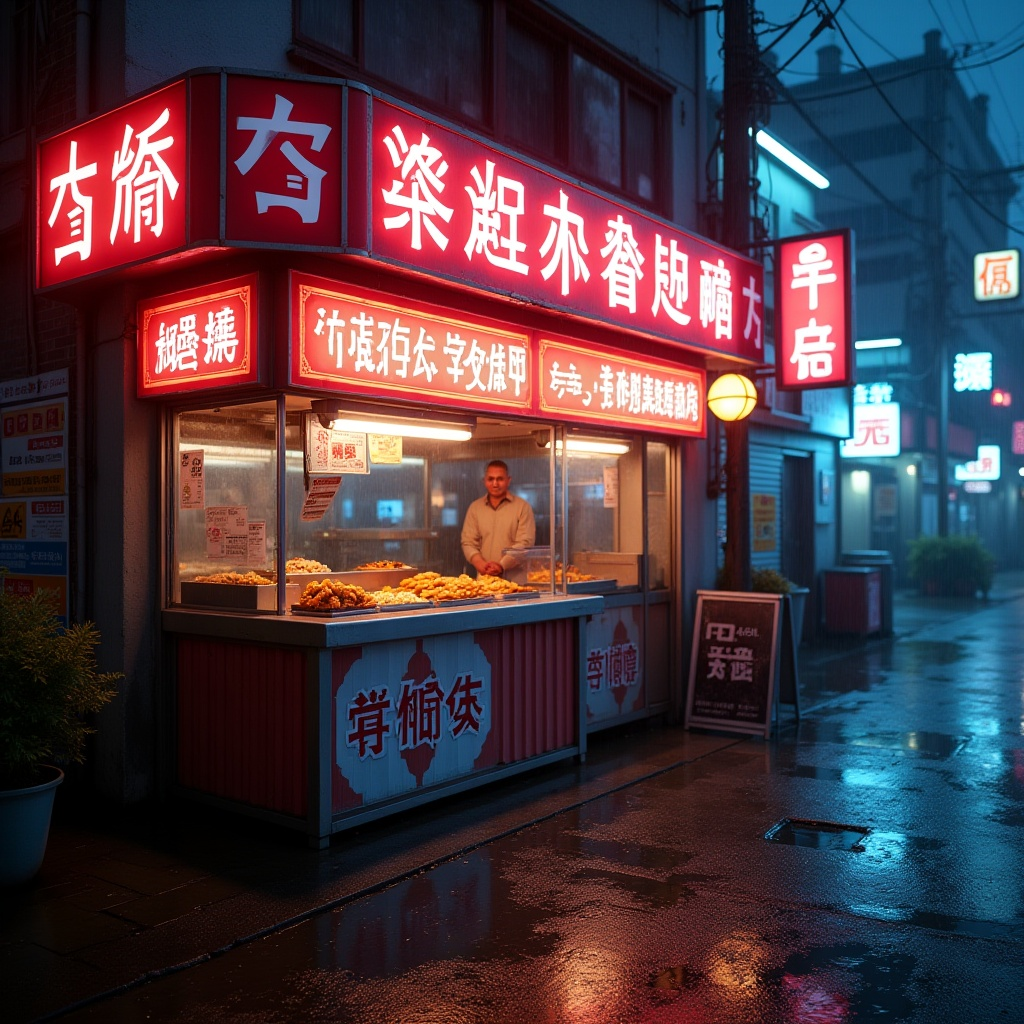

Saved to flux_result.png


In [4]:
from IPython.display import Image, display
import requests

def download_and_display(url, filename="output.png"):
    """Helper to download and display the generated media."""
    response = requests.get(url)
    if response.status_code == 200:
        with open(filename, 'wb') as f:
            f.write(response.content)
        display(Image(filename=filename, width=600))
        print(f"Saved to {filename}")
    else:
        print(f"Failed to download media: {response.status_code}")

# ------------------------------
# Generate an Image
# ------------------------------

print("🎨 Generating image with Flux...")

try:
    # Note: Model IDs may change. Check wavespeed.ai/models for the latest list.
    # Common IDs: 'wavespeed-ai/flux-dev', 'black-forest-labs/flux-1-dev'
    result = client.run(
        "wavespeed-ai/flux-dev", 
        {
            "prompt": "A cyberpunk street food vendor in Tokyo, neon lights, rain reflections, highly detailed, 8k",
            "aspect_ratio": "16:9",
            "guidance_scale": 3.5, # This controls how strictly the AI adheres to your text prompt; wiht lower value, the AI takes more artistic liberties.
            "num_inference_steps": 20 # This is the number of "passes" the AI makes to clear up the image from noise to a final picture; with lower value, faster generation, but the image might look blurry
        }
    )

    # The output is usually a list of URLs
    image_url = result["outputs"][0]["url"] if isinstance(result["outputs"][0], dict) else result["outputs"][0]
    print(f"Generated URL: {image_url}")
    
    download_and_display(image_url, "flux_result.png")

except Exception as e:
    print(f"Error generating image: {e}")

## 4. Image-to-Video Generation (Wan/Kling)

One of WaveSpeed's most powerful features is accelerating video generation models like **Wan 2.1** and **Kling**. These models take an input image (like the one we just created) and animate it based on a prompt.

**Note**: Video generation takes longer than images (typically 30s - 2 mins). The SDK handles the waiting for you.

In [ ]:
from IPython.display import Video

# We will use the image URL generated in the previous step.
# If you skipped that step, replace this with any public image URL.
input_image_url = image_url 

print("🎥 Generating video from image... (This may take a minute)")

try:
    # Using Wan 2.1 (Example ID - verify exact ID on the platform)
    # Other popular options: 'kwaivgi/kling-v2.6-i2v'
    video_result = client.run(
        "wan-ai/wan-2.1-i2v-720p", 
        {
            "image_url": input_image_url,
            "prompt": "The vendor cooks food, steam rising, neon lights flickering, cinematic slow motion",
            "negative_prompt": "distortion, blurry, shaking camera",
            "duration": 5  # Duration in seconds (depends on model capabilities)
        }
    )

    video_output_url = video_result["outputs"][0]["url"] if isinstance(video_result["outputs"][0], dict) else video_result["outputs"][0]
    print(f"Video URL: {video_output_url}")

    # Display Video
    display(Video(url=video_output_url, width=600))

except Exception as e:
    print(f"Error generating video: {e}")

## 5. Advanced: Using LoRA (Low-Rank Adaptation)

WaveSpeed supports LoRAs to apply specific artistic styles or characters to your generations without retraining the entire model. You can point to LoRAs hosted on Hugging Face or Civitai.

In this example, we'll apply a "Papercut" style LoRA to a Flux generation.

In [ ]:
print("🎨 Generating stylized image with LoRA...")

try:
    lora_result = wavespeed.run(
        "wavespeed-ai/flux-dev",
        {
            "prompt": "A cute robot holding a flower, papercut style, intricate details",
            # LoRA configuration syntax depends on the specific model support
            # WaveSpeed often allows passing a 'loras' list or embedding it in the prompt for some models.
            "loras": [
                {
                    "path": "TheMisto/Misto-Flux-Papercut", # Example HF path
                    "scale": 0.8  # Strength of the LoRA
                }
            ],
            "aspect_ratio": "1:1",
            "guidance_scale": 4.0
        }
    )

    lora_url = lora_result["outputs"][0]["url"] if isinstance(lora_result["outputs"][0], dict) else lora_result["outputs"][0]
    download_and_display(lora_url, "lora_result.png")

except Exception as e:
    print(f"Error with LoRA generation: {e}")

## 6. Asynchronous Tasks (For Production)

For building web apps, you don't want to block your code while waiting for a video. WaveSpeed supports Webhooks, but locally you can often use `run_async` patterns or standard Python concurrency if the SDK supports it. 

Below is a conceptual example of how you might structure a batch request if you were processing multiple prompts.

In [ ]:
import concurrent.futures

prompts = [
    "A futuristic city on Mars",
    "An underwater civilization"
]

def generate_batch(prompt):
    print(f"Starting: {prompt}...")
    res = wavespeed.run("wavespeed-ai/flux-dev", {"prompt": prompt})
    return res["outputs"][0]

# Run in parallel threads
# Note: Ensure your API tier supports concurrent requests
try:
    with concurrent.futures.ThreadPoolExecutor(max_workers=2) as executor:
        results = list(executor.map(generate_batch, prompts))
    
    print("Batch generation complete!")
    for i, url in enumerate(results):
        print(f"Result {i+1}: {url}")
except Exception as e:
    print(f"Batch processing error: {e}")

## 📝 Conclusion

You've successfully explored the WaveSpeed AI API! 

**Summary:**
* **Simplicity**: One `run()` function for multiple models.
* **Speed**: Optimized inference for Flux and Wan.
* **Flexibility**: Easy integration of LoRAs and Image-to-Video workflows.

**Next Steps:**
* Explore the [Model Catalog](https://wavespeed.ai/models) for new additions (like Sora 2 or Veo).
* Integrate this into a Streamlit or FastAPI app.
* Check out the [ComfyUI Node](https://github.com/WaveSpeedAI/wavespeed-comfyui) if you prefer a visual workflow.